# Exploratory Data Analysis Report of the Automobiles Dataset
The purpose of this report is to clean, sanitise, and explore the automobile dataset. 
The analysis investigates key relationships between variables such as price, fuel efficiency, engine size, and manufacturer representation.

**This report was written by:** Perryn Richardson

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
import os

# Display chart in the notebook
%matplotlib inline

## 1. Load Data
The purpose of this section is to import the required libraries and load the automobile dataset into a pandas DataFrame for analysis.

In [2]:
# Load the automobiles dataset
automobiles_df = pd.read_csv('Code files/automobile.txt')

# Preview the first few rows
automobiles_df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [3]:
# Save a copy of the raw data before cleaning
automobiles_df.to_csv('Code files/automobiles_raw.csv', index=False)

## 2. Data cleaning
Prepare the dataset for analysis. 
This includes removing unnecessary columns, identifying and handling duplicate rows, replacing missing values, and converting columns to 
the correct data types.

In [4]:
# 2.1) Remove columns not needed for analysis
columns_to_drop = ['symboling', 'normalized-losses']
automobiles_df = automobiles_df.drop(columns=columns_to_drop)

automobiles_df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [5]:
# 2.2) Visual inspection of the data shows possible row duplication
# Identify duplicate rows
duplicates = automobiles_df[automobiles_df.duplicated()]

print(f"Number of duplicate rows: {len(duplicates)}")
print(duplicates)

Number of duplicate rows: 0
Empty DataFrame
Columns: [make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price]
Index: []

[0 rows x 24 columns]


In [6]:
# 2.3) Remove duplicate rows if there are any
automobiles_df = automobiles_df.drop_duplicates()

print(f"Rows after removing duplicates: {len(automobiles_df)}")

Rows after removing duplicates: 205


In [7]:
# 2.4) Initial look at data shows '?' in dataset
# This is misleading when looking for missing values
# Replace '?' with NaN so pandas can recognise missing values
automobiles_df = automobiles_df.replace('?', np.nan)

# Count missing values per column
print(automobiles_df.isnull().sum())

make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64


In [8]:
# 2.5) Remove rows with missing values
automobiles_df = automobiles_df.dropna()

print(f"Rows remaining after dropping missing values: {len(automobiles_df)}")

Rows remaining after dropping missing values: 193


In [9]:
# 2.6) Check current data types
print(automobiles_df.dtypes)

make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object


In [10]:
# 2.7) Convert data types
# Convert whole number columns to int64
int_cols = [
    'horsepower', 'peak-rpm', 'price'
]

# Convert decimal columns to float64
float_cols = [
    'bore', 'stroke', 'wheel-base', 'length',
    'width', 'height', 'compression-ratio'
]

automobiles_df[int_cols] = automobiles_df[int_cols].astype(np.int64)
automobiles_df[float_cols] = automobiles_df[float_cols].astype(np.float64)

print(automobiles_df.dtypes)

make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object


## 3. Exploratory Data Analysis

The purpose of this section is to explore the cleaned automobile dataset 
and answer key questions about pricing, fuel efficiency, engine size, 
and manufacturer representation.

### 3.1 Which automobiles are in the hatchback category?

In [11]:
# Filter to hatchback body style
hatchback_cars = automobiles_df[automobiles_df['body-style'] == 'hatchback']

hatchback_cars

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88.4,141.1,60.3,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94.5,155.9,63.6,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,toyota,gas,std,four,hatchback,fwd,front,102.4,175.6,66.5,...,122,mpfi,3.31,3.54,8.70,92,4200,27,32,9988
177,toyota,gas,std,four,hatchback,fwd,front,102.4,175.6,66.5,...,122,mpfi,3.31,3.54,8.70,92,4200,27,32,11248
178,toyota,gas,std,two,hatchback,rwd,front,102.9,183.5,67.7,...,171,mpfi,3.27,3.35,9.30,161,5200,20,24,16558
179,toyota,gas,std,two,hatchback,rwd,front,102.9,183.5,67.7,...,171,mpfi,3.27,3.35,9.30,161,5200,19,24,15998


### 3.2 Which are the 5 most expensive cars?

In [12]:
# Find the 5 most expensive cars
most_expensive = automobiles_df.sort_values('price', ascending=False).head(5)

most_expensive

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
74,mercedes-benz,gas,std,two,hardtop,rwd,front,112.0,199.2,72.0,...,304,mpfi,3.80,3.35,8.0,184,4500,14,16,45400
16,bmw,gas,std,two,sedan,rwd,front,103.5,193.8,67.9,...,209,mpfi,3.62,3.39,8.0,182,5400,16,22,41315
73,mercedes-benz,gas,std,four,sedan,rwd,front,120.9,208.1,71.7,...,308,mpfi,3.80,3.35,8.0,184,4500,14,16,40960
128,porsche,gas,std,two,convertible,rwd,rear,89.5,168.9,65.0,...,194,mpfi,3.74,2.90,9.5,207,5900,17,25,37028
17,bmw,gas,std,four,sedan,rwd,front,110.0,197.0,70.9,...,209,mpfi,3.62,3.39,8.0,182,5400,15,20,36880


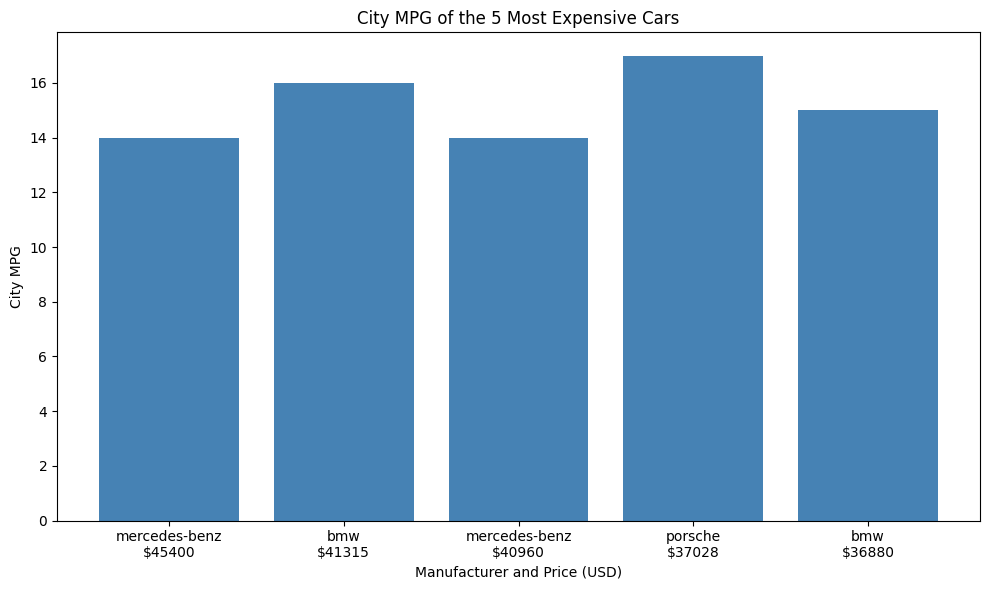

In [13]:
# Create figures folder if it doesn't exist
os.makedirs('Figures', exist_ok=True)

# Bar chart comparing fuel economy of the 5 most expensive cars
plt.figure(figsize=(10, 6))
plt.bar(
    most_expensive['make'] + '\n$' + most_expensive['price'].astype(str),
    most_expensive['city-mpg'],
    color='steelblue'
)
plt.title('City MPG of the 5 Most Expensive Cars')
plt.xlabel('Manufacturer and Price (USD)')
plt.ylabel('City MPG')
plt.tight_layout()
plt.savefig('Figures/most_expensive_cars_mpg.png', dpi=150)
plt.show()

### 3.3 Which manufacturer builds the most fuel efficient vehicles?

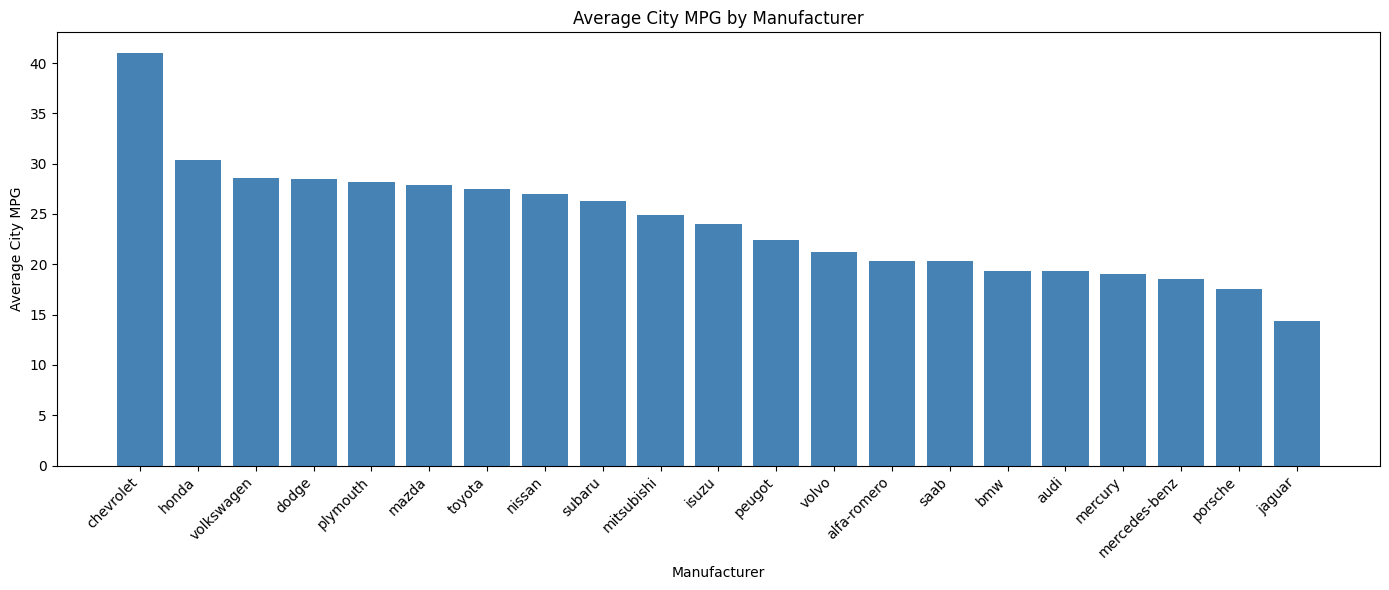

In [14]:
# Average city MPG by manufacturer
avg_mpg = automobiles_df.groupby('make')['city-mpg'].mean().sort_values(
    ascending=False
)

# Bar chart of average city MPG by manufacturer
plt.figure(figsize=(14, 6))
plt.bar(avg_mpg.index, avg_mpg.values, color='steelblue')
plt.title('Average City MPG by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average City MPG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figures/avg_mpg_by_manufacturer.png', dpi=150)
plt.show()

### 3.4 Which vehicles have the largest engine capacity?

In [15]:
# Sort by engine size in descending order
largest_engines = automobiles_df.sort_values('engine-size', ascending=False).head(10)

largest_engines[['make', 'body-style', 'engine-size', 'horsepower', 'price']]

,make,body-style,engine-size,horsepower,price
49,jaguar,sedan,326,262,36000
73,mercedes-benz,sedan,308,184,40960
74,mercedes-benz,hardtop,304,184,45400
47,jaguar,sedan,258,176,32250
48,jaguar,sedan,258,176,35550
71,mercedes-benz,sedan,234,155,34184
72,mercedes-benz,convertible,234,155,35056
17,bmw,sedan,209,182,36880
16,bmw,sedan,209,182,41315
15,bmw,sedan,209,182,30760


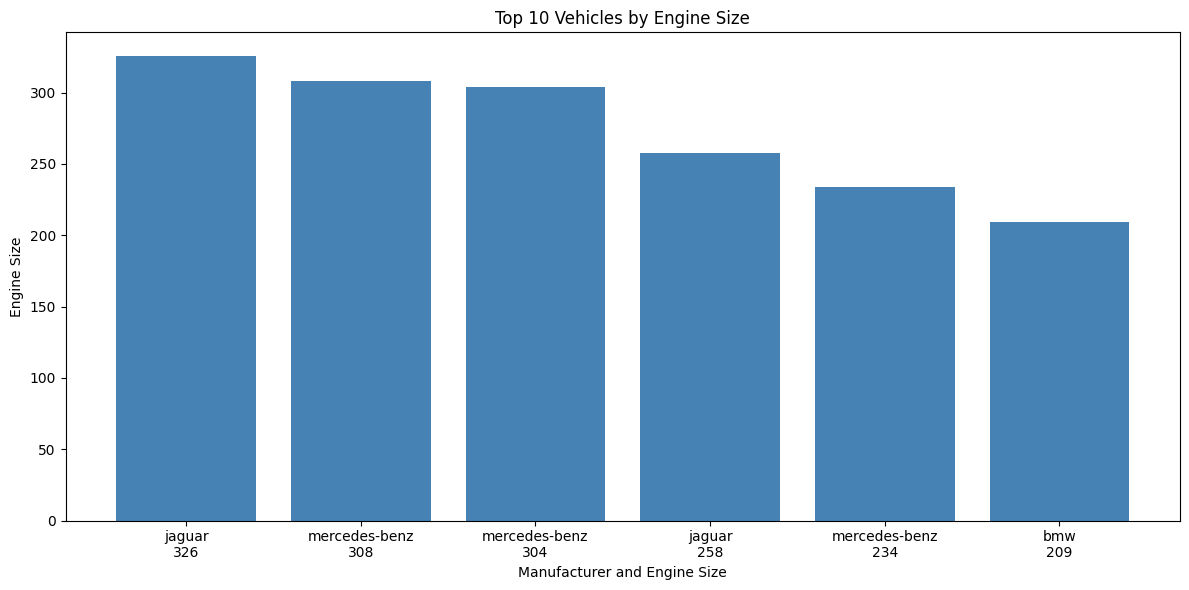

In [16]:
# Bar chart of top 10 largest engine sizes
plt.figure(figsize=(12, 6))
plt.bar(
    largest_engines['make'] + '\n' + largest_engines['engine-size'].astype(str),
    largest_engines['engine-size'],
    color='steelblue'
)
plt.title('Top 10 Vehicles by Engine Size')
plt.xlabel('Manufacturer and Engine Size')
plt.ylabel('Engine Size')
plt.tight_layout()
plt.savefig('Figures/largest_engines.png', dpi=150)
plt.show()

### 3.5 Which vehicle manufacturer has the most car models in the dataset?

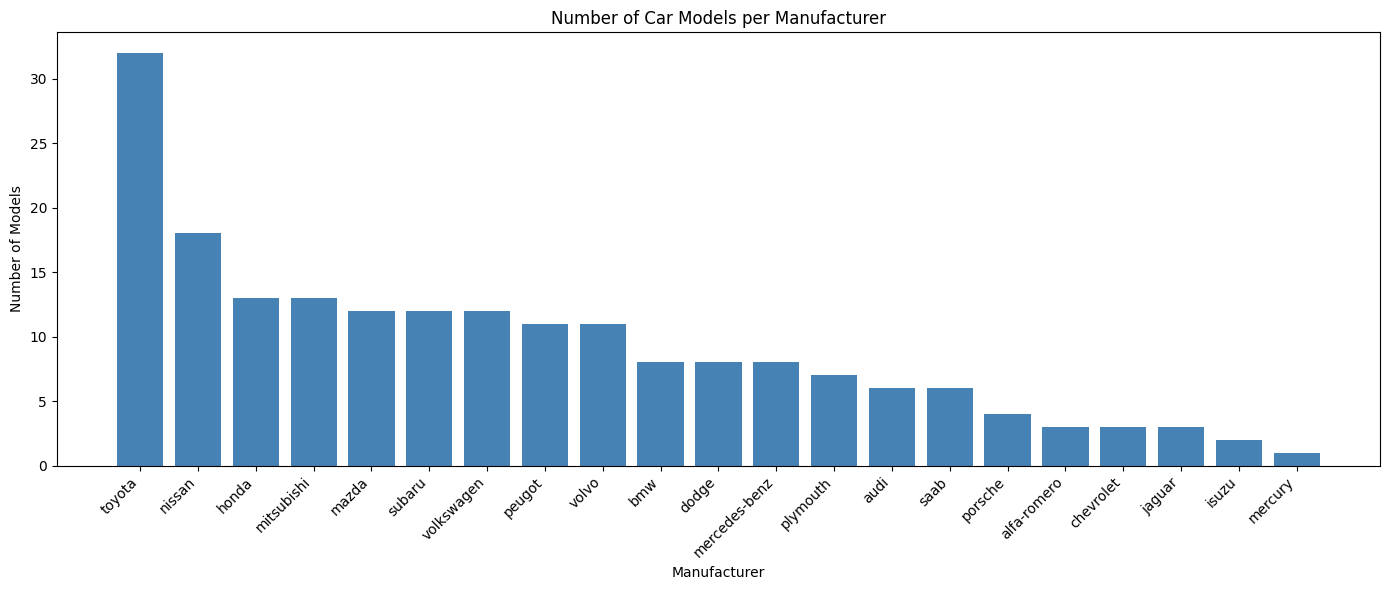

In [17]:
# Count number of models per manufacturer
models_per_make = automobiles_df['make'].value_counts()

# Bar chart of number of models per manufacturer
plt.figure(figsize=(14, 6))
plt.bar(models_per_make.index, models_per_make.values, color='steelblue')
plt.title('Number of Car Models per Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Figures/models_per_manufacturer.png', dpi=150)
plt.show()